[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Segment Images with Segment Anything 3 (SAM3)

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-images-with-segment-anything-3.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://www.youtube.com/watch?v=G1AEuFwQrWU) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/sam3/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/sam3)

SAM 3 (Segment Anything Model 3) extends the SAM series by moving from segmenting individual objects to understanding and segmenting all instances of a concept in images and videos. It introduces Promptable Concept Segmentation (PCS), where users specify a concept through short noun phrases like “striped cat” or by providing visual exemplars. The model detects, segments, and tracks every matching object, preserving identities across frames.


## Environment setup

### Configure your API keys

To pull Segment Anything 3 weights, you need a HuggingFace Access Token with approved access to the SAM 3 checkpoints.

- Request access to the SAM 3 checkpoints on the official Hugging Face [repo](https://github.com/facebookresearch/sam3).
- Open your HuggingFace Settings page. Click Access Tokens then New Token to generate a new token.
- In Colab, go to the left pane and click on Secrets (🔑). Store your HuggingFace Access Token under the name `HF_TOKEN`.








In [4]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [5]:
!nvidia-smi

Sat Jun 20 12:16:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             28W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


### Install SAM 3 and extra dependencies

In [7]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

Cloning into 'sam3'...
remote: Enumerating objects: 1183, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1183 (delta 0), reused 0 (delta 0), pack-reused 1181 (from 2)
Receiving objects: 100% (1183/1183), 60.37 MiB | 43.69 MiB/s, done.
Resolving deltas: 100% (345/345), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to 

/content


In [1]:
!pip install -q supervision jupyter_bbox_widget

### Download example data

Downloads example images. You can use these or replace them with your own images.

In [2]:
!wget -q https://media.roboflow.com/notebooks/examples/solvay_conference_1927.jpg
!wget -q https://media.roboflow.com/notebooks/examples/birds.jpg
!wget -q https://media.roboflow.com/notebooks/examples/pills.jpg
!wget -q https://media.roboflow.com/notebooks/examples/eggs.jpg
!wget -q https://media.roboflow.com/notebooks/examples/traffic_jam.jpg
!wget -q https://media.roboflow.com/notebooks/examples/airport.jpg
!wget -q https://media.roboflow.com/notebooks/examples/basketball_game.jpg
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg

**<font color="red">⚠️ Restart session before running cells below.</font>**








## Load SAM3 Image Predictor

On Ampere GPUs (compute capability ≥ 8), we enable TensorFloat-32 (TF32) for matrix multiplications and convolutions. This allows PyTorch to use tensor cores to accelerate FP32 computations while maintaining similar numerical accuracy.

In [3]:
import torch

torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [4]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

model = build_sam3_image_model(bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz")
processor = Sam3Processor(model, confidence_threshold=0.3)

/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## Few utils to parse and visualize the result

In [5]:
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()

    mask = sam_result["masks"].to(torch.bool)
    mask = mask.reshape(mask.shape[0], mask.shape[2], mask.shape[3]).cpu().numpy()

    return sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        mask=mask
    )

In [6]:
import supervision as sv
from PIL import Image
from typing import Optional


COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])


def annotate(image: Image.Image, detections: sv.Detections, label: Optional[str] = None) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.6
    )
    box_annotator = sv.BoxAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        thickness=1
    )
    label_annotator = sv.LabelAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4,
        text_padding=5,
        text_color=sv.Color.BLACK,
        text_thickness=1
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)

    if label:
        labels = [
            f"{label} {confidence:.2f}"
            for confidence in detections.confidence
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

## SAM 3 text prompt

In [7]:
import os
import numpy as np
import pandas as pd
from PIL import ImageDraw
from datetime import datetime

PROOF_DIR = "/content/violation_proofs"
os.makedirs(PROOF_DIR, exist_ok=True)

violation_log = []  # accumulates metadata across ALL violation types

def save_violation_proof(image, box, violation_type, index, confidence=None, padding=40):
    """
    Draws a box + label on a copy of the image, crops around it with padding
    for context, saves it to disk, and logs the metadata.
    """
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)

    x1, y1, x2, y2 = [int(c) for c in box]
    draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

    label_text = violation_type.upper()
    if confidence is not None:
        label_text += f" ({confidence:.2f})"
    draw.text((x1, max(0, y1 - 18)), label_text, fill="red")

    # Crop with padding so the proof shows context, not just a tight box
    crop_x1 = max(0, x1 - padding)
    crop_y1 = max(0, y1 - padding)
    crop_x2 = min(img_copy.width, x2 + padding)
    crop_y2 = min(img_copy.height, y2 + padding)
    cropped = img_copy.crop((crop_x1, crop_y1, crop_x2, crop_y2))

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    filename = f"{violation_type}_{index}_{timestamp}.jpg"
    filepath = os.path.join(PROOF_DIR, filename)
    cropped.save(filepath)

    violation_log.append({
        "violation_type": violation_type,
        "box": [x1, y1, x2, y2],
        "confidence": float(confidence) if confidence is not None else None,
        "proof_image": filepath,
        "source_image": IMAGE_PATH,
        "timestamp": timestamp,
    })

    return filepath

In [13]:
from google.colab import files

uploaded = files.upload()  # opens a file picker dialog

# Grab the uploaded filename automatically
IMAGE_PATH = list(uploaded.keys())[0]
print(f"Uploaded file saved as: {IMAGE_PATH}")

Saving nightClip5--01295.jpg to nightClip5--01295.jpg
Uploaded file saved as: nightClip5--01295.jpg


There are 2 red traffic light objects detected in the image.



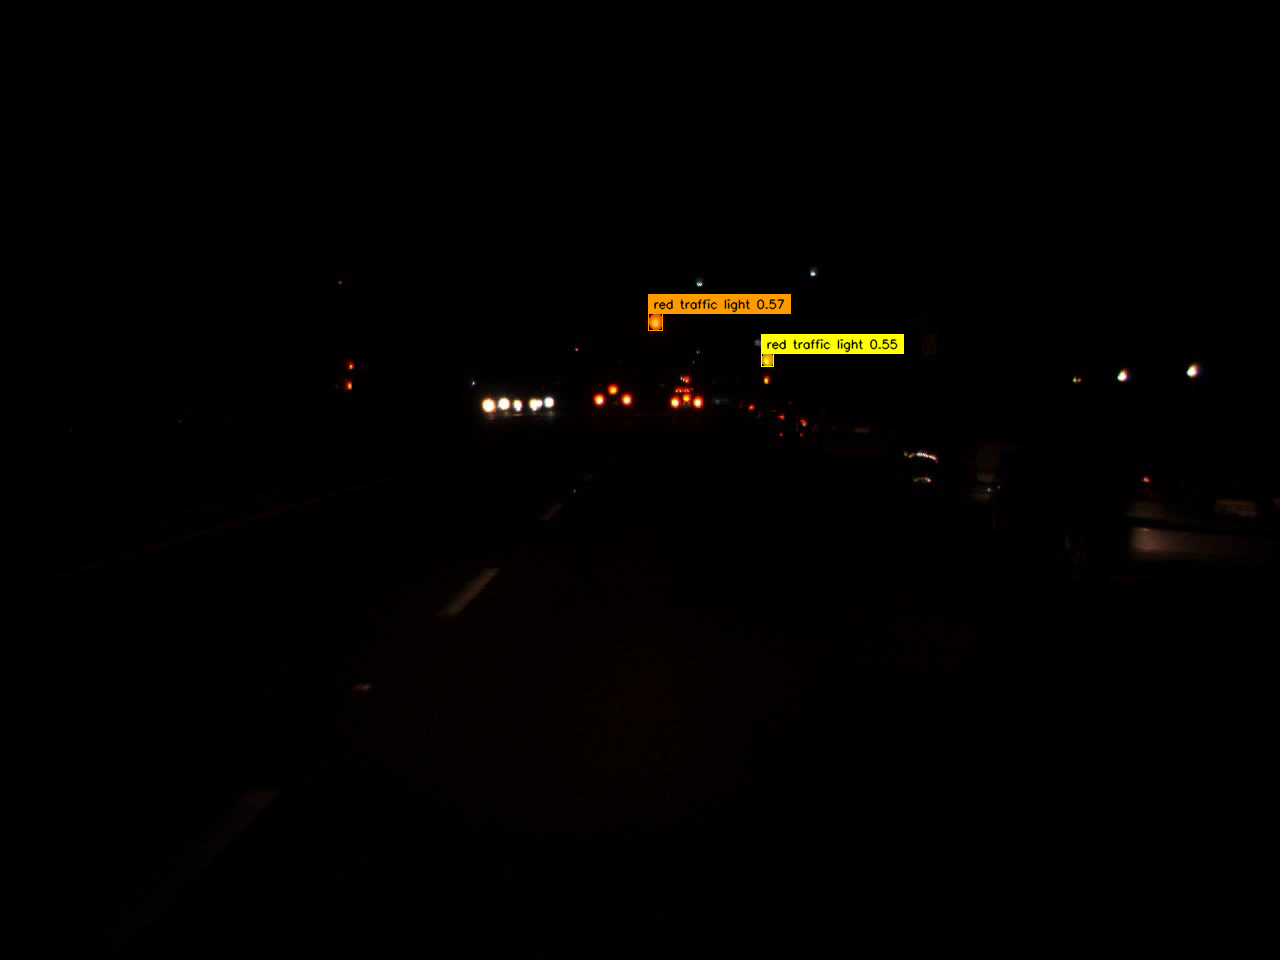

In [15]:
from PIL import Image
from IPython.display import display

PROMPT = "red traffic light"
# IMAGE_PATH = '/content/traffic_jam.jpg'

image = Image.open(IMAGE_PATH).convert("RGB")
inference_state = processor.set_image(image)
inference_state = processor.set_text_prompt(state=inference_state, prompt=PROMPT)

detections = from_sam(sam_result=inference_state)
detections = detections[detections.confidence > 0.5]

print(f"There are {len(detections)} {PROMPT} objects detected in the image.\n")
annotate(image, detections, label=PROMPT)

In [14]:
import os
import numpy as np
import cv2
from PIL import ImageDraw
from datetime import datetime
from IPython.display import display

# ============================================================
# SETUP — helpers used across all violation checks
# ============================================================
OUTPUT_DIR = "/content/violation_proofs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_detections(prompt, conf_thresh=0.5):
    state = processor.set_text_prompt(state=inference_state, prompt=prompt)
    dets = from_sam(sam_result=state)
    return dets[dets.confidence > conf_thresh]

def boxes_overlap(box_a, box_b, expand=15):
    """box format: [x1, y1, x2, y2]. expand grows box_a before checking intersection."""
    ax1, ay1, ax2, ay2 = box_a
    ax1, ay1, ax2, ay2 = ax1 - expand, ay1 - expand, ax2 + expand, ay2 + expand
    bx1, by1, bx2, by2 = box_b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    return inter_x1 < inter_x2 and inter_y1 < inter_y2

def box_center(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def get_light_color(crop_box, img):
    """Crops the traffic light box and checks dominant HSV color."""
    x1, y1, x2, y2 = [int(c) for c in crop_box]
    crop = np.array(img)[y1:y2, x1:x2]
    if crop.size == 0:
        return "unknown"
    hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)
    red_mask = ((hsv[:, :, 0] < 10) | (hsv[:, :, 0] > 170)) & (hsv[:, :, 1] > 100)
    green_mask = (hsv[:, :, 0] > 40) & (hsv[:, :, 0] < 80) & (hsv[:, :, 1] > 100)
    red_count, green_count = red_mask.sum(), green_mask.sum()
    if red_count > green_count and red_count > 20:
        return "red"
    elif green_count > 20:
        return "green"
    return "unknown"

def save_annotated_image(image, boxes, violation_name, color="red"):
    """Draws all violating boxes for one violation type, displays, and saves to disk."""
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    for box in boxes:
        x1, y1, x2, y2 = [int(c) for c in box]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
        draw.text((x1, max(0, y1 - 18)), violation_name.upper(), fill=color)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = os.path.join(OUTPUT_DIR, f"{violation_name}_{timestamp}.jpg")
    img_copy.save(filepath)
    print(f"  -> Proof image saved: {filepath}")
    display(img_copy)
    return filepath

violation_summary = {}

# ============================================================
# 1. TRIPLE RIDING
# ============================================================
print("="*60); print("CHECKING: Triple Riding"); print("="*60)
moto_dets = get_detections("motorcycle")
person_dets = get_detections("person")
print(f"Detected {len(moto_dets)} motorcycles, {len(person_dets)} people.")

triple_riding_boxes = []
for i, moto_box in enumerate(moto_dets.xyxy):
    rider_count = sum(boxes_overlap(moto_box, p_box) for p_box in person_dets.xyxy)
    print(f"  Motorcycle #{i+1}: {rider_count} rider(s)")
    if rider_count >= 3:
        triple_riding_boxes.append(moto_box)

print(f"Triple riding violations: {len(triple_riding_boxes)}")
if triple_riding_boxes:
    save_annotated_image(image, triple_riding_boxes, "triple_riding")
else:
    print("  No triple riding violations.\n")
violation_summary["triple_riding"] = len(triple_riding_boxes)

# ============================================================
# 2. HELMET VIOLATION
# ============================================================
print("="*60); print("CHECKING: Helmet Non-Compliance"); print("="*60)
rider_dets = get_detections("person riding motorcycle")
helmet_dets = get_detections("helmet")
print(f"Detected {len(rider_dets)} riders, {len(helmet_dets)} helmets.")

helmet_violation_boxes = []
for rider_box in rider_dets.xyxy:
    x1, y1, x2, y2 = rider_box
    head_region = [x1, y1, x2, y1 + (y2 - y1) * 0.25]
    has_helmet = any(boxes_overlap(head_region, h_box, expand=5) for h_box in helmet_dets.xyxy)
    if not has_helmet:
        helmet_violation_boxes.append(rider_box)

print(f"Helmet violations: {len(helmet_violation_boxes)}")
if helmet_violation_boxes:
    save_annotated_image(image, helmet_violation_boxes, "no_helmet")
else:
    print("  No helmet violations.\n")
violation_summary["no_helmet"] = len(helmet_violation_boxes)

# ============================================================
# 3. SEATBELT VIOLATION
# ============================================================
print("="*60); print("CHECKING: Seatbelt Non-Compliance"); print("="*60)
driver_dets = get_detections("car driver")
seatbelt_dets = get_detections("seatbelt")
print(f"Detected {len(driver_dets)} drivers, {len(seatbelt_dets)} seatbelts.")

seatbelt_violation_boxes = []
for driver_box in driver_dets.xyxy:
    has_belt = any(boxes_overlap(driver_box, b_box, expand=10) for b_box in seatbelt_dets.xyxy)
    if not has_belt:
        seatbelt_violation_boxes.append(driver_box)

print(f"Seatbelt violations: {len(seatbelt_violation_boxes)}")
if seatbelt_violation_boxes:
    save_annotated_image(image, seatbelt_violation_boxes, "no_seatbelt")
else:
    print("  No seatbelt violations.\n")
violation_summary["no_seatbelt"] = len(seatbelt_violation_boxes)

# ============================================================
# 4. STOP-LINE VIOLATION
# ============================================================
print("="*60); print("CHECKING: Stop-Line Violation"); print("="*60)
stopline_dets = get_detections("stop line")
vehicle_dets = get_detections("vehicle")
print(f"Detected {len(stopline_dets)} stop lines, {len(vehicle_dets)} vehicles.")

stopline_violation_boxes = []
if len(stopline_dets) > 0:
    line_box = stopline_dets.xyxy[0]
    line_y = (line_box[1] + line_box[3]) / 2
    for v_box in vehicle_dets.xyxy:
        if v_box[3] < line_y:  # flip this comparison if your camera angle is reversed
            stopline_violation_boxes.append(v_box)

print(f"Stop-line violations: {len(stopline_violation_boxes)}")
if stopline_violation_boxes:
    save_annotated_image(image, stopline_violation_boxes, "stop_line_violation")
else:
    print("  No stop-line violations (or no stop line detected).\n")
violation_summary["stop_line_violation"] = len(stopline_violation_boxes)

# ============================================================
# 5. RED-LIGHT VIOLATION
# ============================================================
print("="*60); print("CHECKING: Red-Light Violation"); print("="*60)
light_dets = get_detections("traffic light")
print(f"Detected {len(light_dets)} traffic lights.")

red_light_violation_boxes = []
if len(light_dets) > 0 and len(stopline_dets) > 0:
    light_color = get_light_color(light_dets.xyxy[0], image)
    print(f"Detected light color: {light_color}")
    if light_color == "red":
        line_y = (stopline_dets.xyxy[0][1] + stopline_dets.xyxy[0][3]) / 2
        for v_box in vehicle_dets.xyxy:
            if v_box[3] < line_y:
                red_light_violation_boxes.append(v_box)
else:
    print("  Skipped: need both a traffic light and a stop line detected.")

print(f"Red-light violations: {len(red_light_violation_boxes)}")
if red_light_violation_boxes:
    save_annotated_image(image, red_light_violation_boxes, "red_light_violation")
else:
    print("  No red-light violations.\n")
violation_summary["red_light_violation"] = len(red_light_violation_boxes)

# ============================================================
# 6. ILLEGAL PARKING
# ============================================================
print("="*60); print("CHECKING: Illegal Parking"); print("="*60)
parked_dets = get_detections("parked car")
sign_dets = get_detections("no parking sign")
print(f"Detected {len(parked_dets)} parked cars, {len(sign_dets)} no-parking signs.")

PROXIMITY_THRESHOLD = 150  # pixels — tune to your image resolution
illegal_parking_boxes = []
for car_box in parked_dets.xyxy:
    car_center = box_center(car_box)
    for sign_box in sign_dets.xyxy:
        if np.linalg.norm(car_center - box_center(sign_box)) < PROXIMITY_THRESHOLD:
            illegal_parking_boxes.append(car_box)
            break

print(f"Illegal parking violations: {len(illegal_parking_boxes)}")
if illegal_parking_boxes:
    save_annotated_image(image, illegal_parking_boxes, "illegal_parking")
else:
    print("  No illegal parking violations.\n")
violation_summary["illegal_parking"] = len(illegal_parking_boxes)

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL VIOLATION SUMMARY")
print("="*60)
total = sum(violation_summary.values())
for v_type, count in violation_summary.items():
    print(f"  {v_type:30s}: {count}")
print(f"\nTotal violations detected: {total}")
print(f"All proof images saved to: {OUTPUT_DIR}")

CHECKING: Triple Riding
Detected 0 motorcycles, 0 people.
Triple riding violations: 0
  No triple riding violations.

CHECKING: Helmet Non-Compliance
Detected 0 riders, 0 helmets.
Helmet violations: 0
  No helmet violations.

CHECKING: Seatbelt Non-Compliance
Detected 0 drivers, 0 seatbelts.
Seatbelt violations: 0
  No seatbelt violations.

CHECKING: Stop-Line Violation
Detected 0 stop lines, 3 vehicles.
Stop-line violations: 0
  No stop-line violations (or no stop line detected).

CHECKING: Red-Light Violation
Detected 3 traffic lights.
  Skipped: need both a traffic light and a stop line detected.
Red-light violations: 0
  No red-light violations.

CHECKING: Illegal Parking
Detected 0 parked cars, 0 no-parking signs.
Illegal parking violations: 0
  No illegal parking violations.


FINAL VIOLATION SUMMARY
  triple_riding                 : 0
  no_helmet                     : 0
  no_seatbelt                   : 0
  stop_line_violation           : 0
  red_light_violation           : 0
  